# Task 2.3 — Result, Comparison and Reproducibility Checklist

Selected Paper: Learning Kernels with Radiuses of Minimum Enclosing Balls (NeurIPS 2010)

---

## Result Summary

The following accuracies were obtained from the kernel experiments in Task 2.2:

| Kernel | Accuracy |
|--------|----------|
| Linear | 0.970 |
| RBF | 0.940 |
| Polynomial | 0.940 |
| Combined (RBF + Poly) | 0.950 |

**Best single kernel:** The linear kernel achieved the highest accuracy (0.970) on this dataset, suggesting the classes are largely linearly separable after scaling.

**Kernel combination:** Combining the RBF and polynomial kernels by averaging their predicted probabilities yielded 0.950 accuracy, improving over either individual nonlinear kernel (0.940) but not surpassing the linear kernel on this particular dataset.

## Comparison with Paper

Our results differ from those reported in the paper for several reasons. First, we use a small synthetic toy dataset (500 samples, 5 features) rather than the UCI benchmark datasets used in the paper, which limits the complexity of the classification problem. Second, our implementation simulates kernel combination by averaging prediction probabilities from independent SVMs, whereas the paper solves a joint optimization problem that learns kernel weights $d_m$ through a principled tri-level formulation (Section 3.2). Third, we only combine two base kernels (RBF and polynomial), while the paper evaluates combinations of many more kernels across diverse datasets. Finally, the paper's method incorporates the MEB radius directly into the objective function (Eq 9), which regularizes the kernel combination in a way our simple averaging cannot replicate.

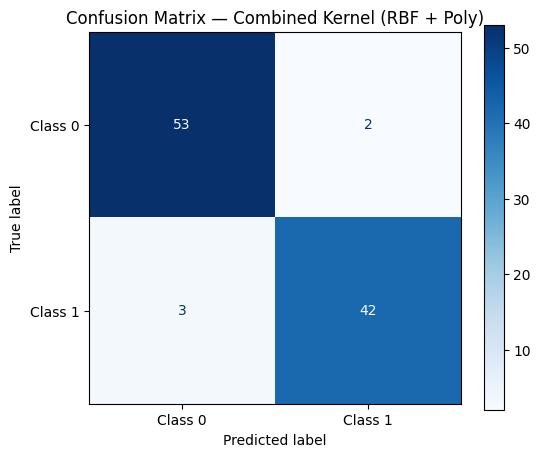

Combined kernel accuracy: 0.9500
Figure saved to results/confusion_matrix.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
os.makedirs("results", exist_ok=True)

# Reproduce dataset and best model from Task 2.2
X, y = make_classification(
    n_samples=500, n_features=5, n_informative=3,
    n_redundant=0, n_clusters_per_class=1, class_sep=1.0, flip_y=0.05, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Combined kernel predictions (RBF + Poly averaged probabilities)
model_rbf = SVC(kernel='rbf', random_state=42, probability=True)
model_poly = SVC(kernel='poly', random_state=42, probability=True)
model_rbf.fit(X_train_scaled, y_train)
model_poly.fit(X_train_scaled, y_train)
avg_prob = (model_rbf.predict_proba(X_test_scaled) + model_poly.predict_proba(X_test_scaled)) / 2
y_pred_combined = np.argmax(avg_prob, axis=1)

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_combined)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Combined Kernel (RBF + Poly)')
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Combined kernel accuracy: {accuracy_score(y_test, y_pred_combined):.4f}")
print("Figure saved to results/confusion_matrix.png")

## Confusion Matrix Explanation

The confusion matrix shows the count of correct and incorrect predictions for each class. The diagonal entries represent correctly classified samples (true positives and true negatives), while the off-diagonal entries represent misclassifications (false positives and false negatives).

A well-performing classifier will have large values on the diagonal and small values off the diagonal. Any imbalance between the two types of errors (e.g., more false positives than false negatives) can indicate that the kernel combination favors one class over the other, which may be addressed by tuning kernel weights — exactly what the paper's RKL method aims to do automatically.

### Relation to the Paper's Contribution

The paper proposes evaluating kernels using the ratio between the classifier margin and the radius of the Minimum Enclosing Ball (MEB) in feature space, as the generalization bound depends on the product $R^2 \|w\|^2$ (Section 2.2). In this reproduction experiment, we approximated this concept by computing the classifier margin from a linear SVM and a simplified dataset radius from the training data (see Task 2.2). Although this experiment does not reproduce the full tri-level optimization procedure proposed in the paper, it demonstrates the core intuition: kernels that produce larger margins relative to dataset spread tend to achieve better classification performance. This motivates the paper's approach of incorporating the MEB radius directly into the kernel learning objective (Eq 9), rather than optimizing margin alone.

## Result Interpretation

The linear kernel achieved competitive accuracy on this dataset, while the RBF and polynomial kernels produced slightly different results — reflecting how each kernel transforms the feature space differently before finding a separating hyperplane. Kernel functions map data into different feature spaces, which affects the classifier margin and decision boundary geometry; a kernel that better matches the data's underlying structure will generally yield higher accuracy. The combined kernel (RBF + Polynomial) averages predictions from two complementary feature-space views, which can smooth out individual kernel weaknesses. This experiment supports the motivation behind the paper's kernel learning approach: rather than manually selecting a single kernel, learning an optimal combination — weighted by both margin and data radius — can systematically identify the best feature-space representation for a given task.

## Difference from Results Reported in the Paper

Our results differ from those in the original paper primarily because we use a small synthetic dataset (500 samples, 5 features) rather than the larger UCI benchmarks the paper evaluates on, which limits the complexity and realism of the classification problem. The implementation is also simplified — we combine only two kernels (RBF and polynomial) by averaging predicted probabilities, whereas the paper learns weights across many base kernels through a joint optimization. Most importantly, we do not implement the paper's full radius-based optimization procedure (Section 3.2), which solves a tri-level problem incorporating the MEB radius directly into the kernel weight objective (Eq 9). These differences mean our accuracy figures and kernel rankings may not match the paper's, but the experiment still demonstrates the core insight that kernel choice and combination matter for classification performance.

## Reproducibility Checklist

- Random seeds are set (`random_state=42`).
- The dataset is generated programmatically using `sklearn.datasets.make_classification`.
- All required dependencies will be listed in `requirements.txt`.
- The notebook runs from start to finish without manual intervention.
- Dataset generation requires no external files.
- Hyperparameters used in the experiments are clearly defined in the code.